# Vacua Storage

**What's in this notebook?** This notebook demonstrates how to generate, store, query, and curate flux vacuum solutions using the StringForge vacua storage and vault system. The worked examples use **real SUSY vacua** computed with JAXVacua solvers.

**What you will learn:**

1. Generate SUSY vacua with four ISD sampling modes, random sampling, and flux bounding
2. Store vacua with method labels, tags, and run IDs
3. Query and filter stored vacua by method, model, and custom criteria
4. Designate validated solutions as permanent records
5. Work with multiple models (local and from HuggingFace)

**Prerequisites:** Notebooks 2 (overview), 5 (finding flux vacua), 7 (ISD sampling).


## 1. Setup


In [1]:
import warnings
import tempfile
import numpy as np

import jax
import jax.numpy as jnp
jax.config.update("jax_enable_x64", True)

from scipy.optimize import root
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams.update({
    "figure.dpi": 200, "font.size": 10, "axes.labelsize": 11,
    "figure.figsize": (7, 3), "legend.frameon": False,
    "font.family": "serif", "xtick.direction": "in", "ytick.direction": "in",
})

import jaxvacua as jvc
from stringforge import LCSDatabase as CYDatabase

warnings.filterwarnings('ignore')

# Create a temporary database for this demo (cleaned up at the end)
tmpdir = tempfile.mkdtemp(prefix="jaxvacua_demo_")

# Sandbox both the cache and the vault under tmpdir so the demo
# does not pollute the user's real vault.  STRINGFORGE_VAULT must
# be set BEFORE any `designate_vacua(...)` call — `_resolve_vault_dir()`
# raises `LookupError` if neither the env var nor a stringforge repo
# checkout is found (see §11 below for the three resolution stages).
import os, stringforge as sj
sj.set_vault_dir(os.path.join(tmpdir, "vault"))

db = CYDatabase.from_local(tmpdir)
print(f"Demo database: {db.cache_dir}")
print(f"Demo vault:    {os.environ['STRINGFORGE_VAULT']}")


Demo database: /var/folders/p7/f3t072gd3rbfgb00y3hj7dwc0000gn/T/jaxvacua_demo_ol_3rxw_/tdf
Demo vault:    /var/folders/p7/f3t072gd3rbfgb00y3hj7dwc0000gn/T/jaxvacua_demo_ol_3rxw_/vault


## 2. Model A: CP$[1,1,1,6,9]$ at $h^{2,1}=2$

We use the degree-18 hypersurface in $\mathbb{CP}[1,1,1,6,9]$, loaded via the local `model_ID=1` path.


In [2]:
model_A = jvc.FluxVacuaFinder(h12=2, model_ID=1, model_type="KS", maximum_degree=2)
model_A.lcs_tree.a_matrix = jnp.array([[4.5, 1.5], [1.5, 0.]])
sampler = jvc.data_sampler(model_A,flux_bounds=[-5,5])

print(f"h12 = {model_A.h12}, n_fluxes = {model_A.n_fluxes}")
print(f"D3 tadpole = {model_A.D3_tadpole}")


Restricted license - for non-production use only - expires 2026-11-23
h12 = 2, n_fluxes = 6
D3 tadpole = 276


### Helper: solve and collect

We define a small helper that takes ISD initial guesses, solves `$D_i W = 0$` via `scipy.optimize.root`, and returns the converged solutions.


In [3]:
def solve_from_guesses(model, z0, tau0, fluxes0, tol=1e-10, residual_tol=1e-6):
    """Solve DW=0 for each (z, tau, flux) triple. Return converged solutions."""
    moduli_out, tau_out, flux_out = [], [], []
    for i in range(len(z0)):
        x0 = model._convert_complex_to_real(
            z0[i], jnp.conj(z0[i]), tau0[i], jnp.conj(tau0[i])
        )
        r = root(model.DW_x, x0, args=(fluxes0[i],),
                 jac=model.dDW_x, method="hybr", tol=tol)
        residual = float(np.max(np.abs(r.fun)))
        if residual < residual_tol:
            m, _, t, _ = model._convert_real_to_complex(r.x)
            if not np.any(np.isnan(np.append(m, t))):
                moduli_out.append(m)
                tau_out.append(t)
                flux_out.append(fluxes0[i])
    if len(moduli_out) == 0:
        return jnp.zeros((0, model.h12)), jnp.zeros(0), jnp.zeros((0, 2*model.n_fluxes))
    return jnp.array(moduli_out), jnp.array(tau_out), jnp.array(flux_out)


## 3. Generating vacua with different sampling methods

We generate SUSY vacua using four ISD modes and store each batch separately, labelled by method.


### ISD sampling (4 modes)

ISD (Imaginary Self-Dual) sampling exploits the ISD condition $\star G_3 = \mathrm{i} G_3$ to construct flux vectors that approximately satisfy the F-term equations. Given a random moduli point $(z^a, \tau)$ and half of the flux quanta, the ISD condition fixes the remaining fluxes analytically. After rounding to integers, a short Newton solve finds the nearby exact SUSY vacuum.

Four modes are available:
- **ISD+** / **ISD-**: solve the ISD condition for the upper/lower flux components
- **F**: fix the NSNS-flux $h$ and derive the RR-flux $f$
- **H**: fix the RR-flux $f$ and derive the NSNS-flux $h$

Each mode explores a different region of the flux landscape and yields a different set of vacua.


In [4]:
Nmax = 276
N_candidates = 50

for isd_mode in ["ISD+", "ISD-", "F", "H"]:
    # Generate ISD initial guesses
    z0, tau0, fluxes0 = sampler.initial_guesses_ISD(
        N=N_candidates, Nmax=Nmax, mode=isd_mode, 
        moduli_sampling_mode="cone", ISD_oversample_factor=2,
        print_progress=True, filter_moduli=True
    )
    
    # Solve for SUSY vacua
    moduli, tau, fluxes = solve_from_guesses(model_A, z0, tau0, fluxes0)
    
    print(f"{isd_mode:5s}: {len(moduli)}/{N_candidates} converged")
    
    # Store in database
    if len(moduli) > 0:
        with db.vacua_writer(model=model_A, method=isd_mode) as w:
            w.append_batch(moduli, tau, fluxes, is_susy=np.ones(len(moduli), dtype=bool))
        print(f"       Stored {w.count} vacua (run_id: {w._run_id[:8]}...)")


ISD+ : 41/50 converged  
       Stored 41 vacua (run_id: 369c393a...)
ISD- : 22/50 converged  
       Stored 22 vacua (run_id: 9b464300...)
F    : 29/50 converged  
       Stored 29 vacua (run_id: d1e5e8bd...)
H    : 39/50 converged  
       Stored 39 vacua (run_id: 805a9e7e...)


### Random uniform sampling

Sample moduli and fluxes uniformly at random, then solve.


In [5]:
rng = np.random.default_rng(42)
N_random = 100

# Random moduli in the Kahler cone
z_rand = jnp.array(rng.uniform(-0.5, 0.5, (N_random, 2)) + 1j * rng.uniform(2, 5, (N_random, 2)))
tau_rand = jnp.array(rng.uniform(-0.5, 0.5, N_random) + 1j * rng.uniform(1, 10, N_random))
flux_rand = jnp.array(rng.integers(-5, 6, (N_random, 2 * model_A.n_fluxes)), dtype=float)

# Filter by tadpole
sigma = np.array(model_A.periods.sigma)
nf = model_A.n_fluxes
tad = np.array([abs(flux_rand[i, :nf] @ sigma @ flux_rand[i, nf:]) for i in range(N_random)])
mask = (tad > 0) & (tad <= Nmax)
z_rand, tau_rand, flux_rand = z_rand[mask], tau_rand[mask], flux_rand[mask]

moduli_r, tau_r, flux_r = solve_from_guesses(model_A, z_rand, tau_rand, flux_rand)
print(f"random: {len(moduli_r)}/{len(z_rand)} converged (from {N_random} initial)")

if len(moduli_r) > 0:
    with db.vacua_writer(model=model_A, method="random") as w:
        w.append_batch(moduli_r, tau_r, flux_r, is_susy=np.ones(len(moduli_r), dtype=bool))
    print(f"       Stored {w.count} vacua")


random: 42/100 converged (from 100 initial)
       Stored 42 vacua


### Flux bounding (systematic enumeration)

Use `bounded_fluxes.enumerate_fluxes` with a small $N_\text{max}$ for a quick systematic scan.


In [ ]:
from jaxvacua.flux_bounding import bounded_fluxes

bf = bounded_fluxes(model_A, sampler, Nmax=Nmax)
enum_results = bf.sample_bounded_fluxes(n_sample=50, n_batch=50, n_target=50, n_mod=5, refine=True, verbose=True)

if len(enum_results) > 0:
    # Extract arrays
    m_enum = jnp.array([r["moduli"] for r in enum_results])
    t_enum = jnp.array([r["tau"] for r in enum_results])
    f_enum = jnp.array([r["flux"] for r in enum_results])
    
    with db.vacua_writer(model=model_A, method="flux_bounding") as w:
        w.append_batch(m_enum, t_enum, f_enum, is_susy=np.ones(len(m_enum), dtype=bool))
    print(f"flux_bounding: Stored {w.count} vacua from {len(enum_results)} results")
else:
    print("flux_bounding: No results (try increasing Nmax or n_sample)")


[sample_bounded] Moduli region: sampler-defined
[sample_bounded] Step 1 — Sampling 50 moduli points and computing eigenvalue bounds ...
[sample_bounded]   λ_max=214.6011, μ_min=0.0468, μ̃_min=0.0047  [0.9s]
[sample_bounded]   Bounding box: h1_box=211.15, h2_box=66.65, h_box=267.54
[sample_bounded] Step 2 — Preparing ISD kernels (5 moduli points) ...
[sample_bounded]   5 ISD moduli points.  [1.0s]
[sample_bounded] Stochastic search: target=50, batch_size=10, n_mod=5, max_batches=100  [1.0s]
[sample_bounded]   Batch 1/100 | found 0/50 | candidates: 1, converged: 1/1, in-patch: 0/1  [4.3s]
[sample_bounded]   Batch 2/100 | found 0/50 | candidates: 1, converged: 1/1, in-patch: 0/1  [4.3s]
[sample_bounded]   Batch 3/100 | found 0/50 | 30 tried, yield 0.00%  [4.4s]
[sample_bounded]   Batch 4/100 | found 0/50 | candidates: 3, converged: 2/3, in-patch: 0/2  [7.1s]
[sample_bounded]   Batch 5/100 | found 0/50 | 50 tried, yield 0.00%  [7.2s]
[sample_bounded]   Batch 6/100 | found 0/50 | 60 tried, 

### Perturbatively flat vacua (PFVs)

PFVs are a special class of flux vacua where the polynomial superpotential vanishes exactly along a flat direction $z^a = p^a \tau$. The vacuum is lifted only by exponentially suppressed instanton corrections, leading to very small $|W_0|$.

The PFV is specified by integer vectors $(M^a, K_a)$ satisfying (see [arXiv:2512.17095](https://arxiv.org/abs/2512.17095), Section 6.2):
- $\det(N) \neq 0$ where $N_{ab} = \kappa_{abc} M^c$
- $p^a = (N^{-1} K)^a \in \mathcal{K}_{\widetilde{X}}$ (Kahler cone)
- $K_a p^a = 0$ (orthogonality)

`pfv_to_flux(M, K)` constructs the full flux vector, and `pfv_to_moduli(M, K, tau)` gives the flat-direction starting point.


In [7]:
# PFV example from arXiv:2501.03984 (Table 1)
M_pfv = jnp.array([-16, 50])
K_pfv = jnp.array([3, -4])
gs = 0.2  # string coupling

flux_pfv = model_A.pfv_to_flux(M_pfv, K_pfv)
tau0_pfv = 1j / gs
z0_pfv = model_A.pfv_to_moduli(M_pfv, K_pfv, tau0_pfv)

print(f"PFV flux: {np.array(flux_pfv, dtype=int)}")
print(f"Starting moduli: z = {z0_pfv}")
print(f"Starting tau:    {tau0_pfv}")

# Newton warm-start (PFV starting point is close but not exact)
z_n, tau_n, _ = model_A.newton_method_flux_vacua(
    z0_pfv, tau0_pfv, flux_pfv,
    step_size_Newton=0.5, tol=1e-12, max_iters=100,
    mode="SUSY", solver_mode="real",
)

# scipy polish
x_n = np.array(model_A._convert_complex_to_real(z_n, jnp.conj(z_n), tau_n, jnp.conj(tau_n)))
r_pfv = root(model_A.DW_x, x_n, args=(flux_pfv,), jac=model_A.dDW_x, method="hybr", tol=1e-12)
residual = float(np.max(np.abs(r_pfv.fun)))

if residual < 1e-6:
    z_pfv, _, tau_pfv, _ = model_A._convert_real_to_complex(jnp.array(r_pfv.x))
    W0 = model_A.superpotential_gauge_invariant(z_pfv, tau_pfv, flux_pfv)
    print(f"\nConverged! |W0_gi| = {abs(complex(W0)):.6e}  (|DW| = {residual:.2e})")
    print(f"z  = {z_pfv}")
    print(f"tau = {tau_pfv}")
    
    # Store as PFV with tags
    with db.vacua_writer(model=model_A, method="PFV",
                         metadata={"M": M_pfv.tolist(), "K": K_pfv.tolist(), "gs": gs}) as w:
        w.append({"moduli": np.array(z_pfv), "tau": complex(tau_pfv),
                  "flux": np.array(flux_pfv)},
                 tags=["racetrack", "small_W0"])
    print(f"Stored PFV vacuum (run_id: {w._run_id[:8]}...)")
else:
    print(f"PFV did not converge (|DW| = {residual:.2e})")


PFV flux: [  7   3 -24   0 -16  50   0   3  -4   0   0   0]
Starting moduli: z = [0.+2.j  0.+1.5j]
Starting tau:    5j

Converged! |W0_gi| = 2.037112e-08  (|DW| = 1.29e-14)
z  = [-2.82421661e-10+2.74217626j -2.11815726e-10+2.05663223j]
tau = (-7.060311838346165e-10+6.855455455317841j)
Stored PFV vacuum (run_id: fb9bd3f3...)


In [8]:
# Scan over several PFV (M, K) pairs
pfv_pairs = [
    ([-16, 50], [3, -4], 0.2),
    ([-8, 25],  [3, -4], 0.3),
    ([4, -8],   [8, -3], 0.15),
    ([-10, 30], [3, -4], 0.12),
]

pfv_moduli, pfv_tau, pfv_flux = [], [], []
for M_list, K_list, gs_val in pfv_pairs:
    M_i = jnp.array(M_list)
    K_i = jnp.array(K_list)
    fl_i = model_A.pfv_to_flux(M_i, K_i)
    tau_i = 1j / gs_val
    z_i = model_A.pfv_to_moduli(M_i, K_i, tau_i)
    
    try:
        # Newton warm-start + scipy polish
        z_n, tau_n, _ = model_A.newton_method_flux_vacua(
            z_i, tau_i, fl_i, step_size_Newton=0.5, tol=1e-12,
            max_iters=100, mode="SUSY", solver_mode="real",
        )
        x_n = np.array(model_A._convert_complex_to_real(z_n, jnp.conj(z_n), tau_n, jnp.conj(tau_n)))
        r_i = root(model_A.DW_x, x_n, args=(fl_i,), jac=model_A.dDW_x, method="hybr", tol=1e-12)
        residual = float(np.max(np.abs(r_i.fun)))
        
        if residual < 1e-6:
            m_i, _, t_i, _ = model_A._convert_real_to_complex(jnp.array(r_i.x))
            W_i = abs(complex(model_A.superpotential_gauge_invariant(m_i, t_i, fl_i)))
            pfv_moduli.append(m_i)
            pfv_tau.append(t_i)
            pfv_flux.append(fl_i)
            print(f"M={M_list}, K={K_list}, gs={gs_val}: |W0_gi|={W_i:.4e}")
        else:
            print(f"M={M_list}, K={K_list}, gs={gs_val}: did not converge (|DW|={residual:.2e})")
    except Exception as e:
        print(f"M={M_list}, K={K_list}, gs={gs_val}: error — {e}")

if len(pfv_moduli) > 0:
    with db.vacua_writer(model=model_A, method="PFV_scan") as w:
        w.append_batch(jnp.array(pfv_moduli), jnp.array(pfv_tau), jnp.array(pfv_flux),
                       is_susy=np.ones(len(pfv_moduli), dtype=bool),
                       tags=["racetrack"])
    print(f"\nStored {w.count} PFV vacua")


M=[-16, 50], K=[3, -4], gs=0.2: |W0_gi|=2.0371e-08
M=[-8, 25], K=[3, -4], gs=0.3: |W0_gi|=1.4405e-08
M=[4, -8], K=[8, -3], gs=0.15: did not converge (|DW|=nan)
M=[-10, 30], K=[3, -4], gs=0.12: did not converge (|DW|=nan)

Stored 1 PFV vacua


### Summary of SUSY vacua

Let us visualise the vacua collected so far across all sampling methods.


In [9]:
all_runs = db.query_vacua(h12=2)
all_runs.head(5)

,vacuum_id,flux,moduli_re,moduli_im,tau_re,tau_im,W_re,W_im,F_terms_re,F_terms_im,...,triang_id,conifold_id,cicy_id,model_hash,model_name,method,created,metadata,moduli,tau
0,0,"[21, 19, 0, -1, -2, -2, 4, 21, 7, 0, 2, -2]","[-0.46836663972052406, -0.06922841920969769]","[0.46448869675076043, 0.9297221483816526]",-0.134633,2.837700,None,None,None,None,...,-1,-1,-1,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(-0.46836663972052406+0.46448869675076043j), ...",-0.134633+2.837700j
1,1,"[40, -19, 3, 4, 5, 3, 4, -10, -3, 0, -1, 2]","[0.5296880796408124, -0.32023796208904753]","[0.4911621870478364, 1.8494163401942396]",-0.067452,3.810561,None,None,None,None,...,-1,-1,-1,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.5296880796408124+0.4911621870478364j), (-0...",-0.067452+3.810561j
2,2,"[0, 20, 7, 5, -5, 0, -1, 26, 6, 1, 1, 2]","[0.09064033216355658, -0.7494641273900575]","[0.9757830327951234, 1.0270404583300263]",0.206257,2.737421,None,None,None,None,...,-1,-1,-1,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.09064033216355658+0.9757830327951234j), (-...",0.206257+2.737421j
3,3,"[-18, 34, 6, -4, 0, 4, 9, -2, -2, 0, 0, 4]","[0.38429692383686975, -0.2862658984674867]","[0.4155502073436528, 3.61461514143811]",0.311495,7.921757,None,None,None,None,...,-1,-1,-1,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.38429692383686975+0.4155502073436528j), (-...",0.311495+7.921757j
4,4,"[34, -54, 22, 3, 5, -5, 0, -12, -2, 0, -1, 5]","[0.3809191630812639, 0.611255378328325]","[0.9389060403121477, 4.419512636629724]",-0.487857,5.568850,None,None,None,None,...,-1,-1,-1,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.3809191630812639+0.9389060403121477j), (0....",-0.487857+5.568850j


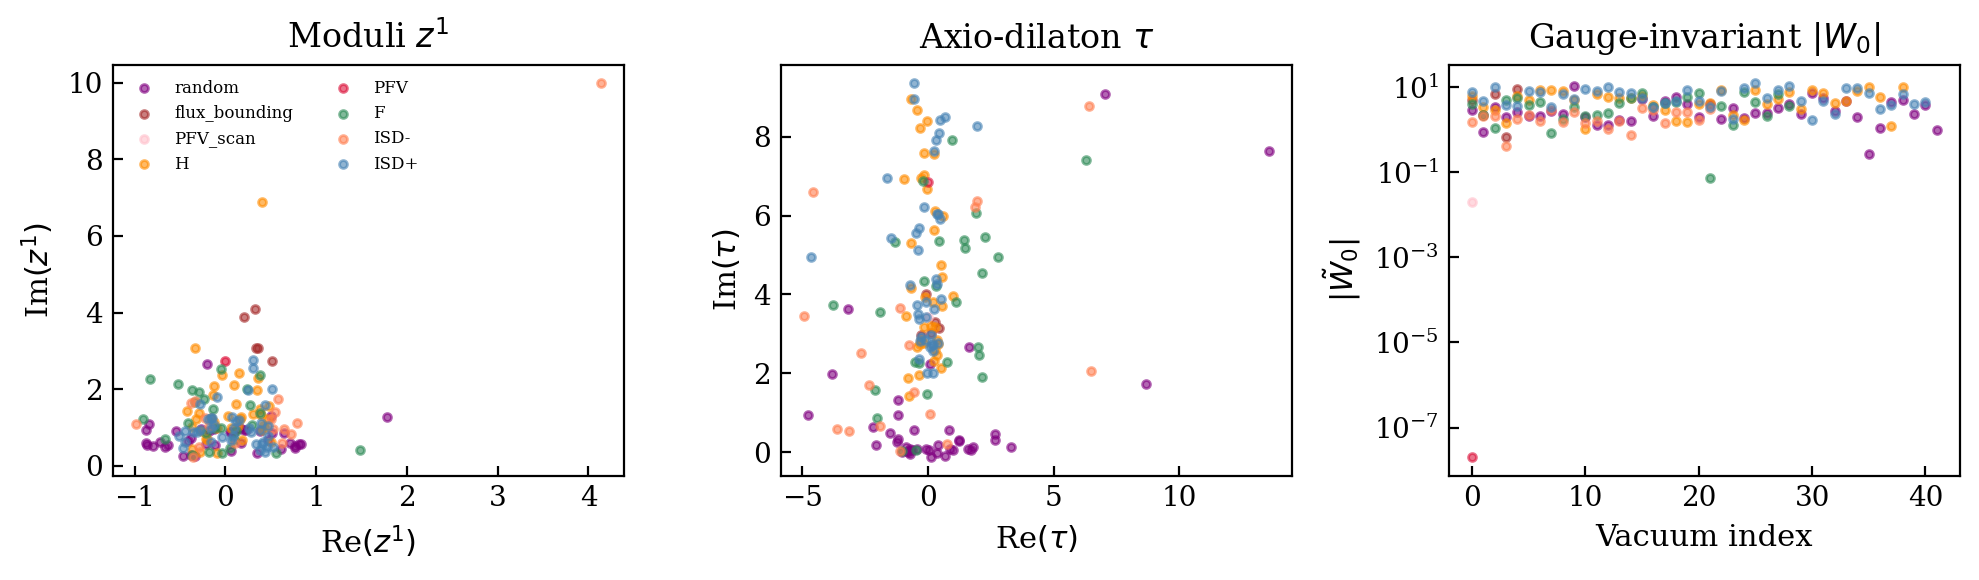

In [10]:
# Collect all SUSY vacua and plot
if len(all_runs) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    colors = {"ISD+": "steelblue", "ISD-": "coral", "F": "seagreen", "H": "darkorange",
              "random": "purple", "flux_bounding": "brown", "PFV": "crimson", "PFV_scan": "pink"}
    
    run_ids = list({x for x in all_runs['run_id'].to_list()})
    
    for run_id in run_ids:
        run_row = all_runs[all_runs['run_id'] == run_id].iloc[0]
        method = run_row["method"]
        try:
            df = db.load_vacua(run_id=run_id)
        except Exception:
            continue
        if len(df) == 0:
            continue
        
        z_arr = np.array(df["moduli"].tolist())
        tau_arr = np.array(df["tau"].tolist())
        c = colors.get(method, "gray")
        
        flag = (np.all(np.abs(z_arr.imag) < 10, axis=1)) & (np.abs(tau_arr.imag) < 10)
        z_arr = z_arr[flag]
        tau_arr = tau_arr[flag]
        
        axes[0].scatter(z_arr[:, 0].real, z_arr[:, 0].imag, s=8, c=c, alpha=0.6, label=method)
        axes[1].scatter(tau_arr.real, tau_arr.imag, s=8, c=c, alpha=0.6)
        
        # Compute |W0| for each vacuum
        for j in range(len(df)):
            row = df.iloc[j]
            try:
                W0 = abs(complex(model_A.superpotential_gauge_invariant(
                    jnp.array(row["moduli"]), complex(row["tau"]), jnp.array(row["flux"]))))
                axes[2].scatter(j, W0, s=8, c=c, alpha=0.6)
            except Exception:
                pass
    
    axes[0].set_xlabel(r"Re$(z^1)$")
    axes[0].set_ylabel(r"Im$(z^1)$")
    axes[0].set_title("Moduli $z^1$")
    # Remove duplicate labels
    handles, labels = axes[0].get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    axes[0].legend(by_label.values(), by_label.keys(), fontsize=6, ncol=2)
    
    axes[1].set_xlabel(r"Re$(\tau)$")
    axes[1].set_ylabel(r"Im$(\tau)$")
    axes[1].set_title(r"Axio-dilaton $\tau$")
    
    axes[2].set_xlabel("Vacuum index")
    axes[2].set_ylabel(r"$|\tilde{W}_0|$")
    axes[2].set_yscale("log")
    axes[2].set_title(r"Gauge-invariant $|W_0|$")
    
    fig.tight_layout()
    plt.show()
else:
    print("No vacua stored yet")


## 4. Non-SUSY critical points

The earlier sections solved the **SUSY** conditions $D_I W = 0$. A generic critical point of the scalar potential satisfies only $\partial_\phi V = 0$ and need not be supersymmetric. Note that perturbing a SUSY solution at **fixed flux** cannot reach a new one — at a fixed SUSY flux the only critical point of $V$ is that SUSY point itself. We therefore use the finder's built-in critical-point sampler `sample_critical_points`, which draws fresh Gaussian-prior fluxes, ISD-completes them, and refines $\partial_\phi V = 0$ with a hybrid optax→Newton solver, classifying each solution (SUSY vs non-SUSY, minimum vs saddle) from the Hessian of $V$.

In [12]:
# Sample genuine critical points of V (dV/dphi = 0) — NOT perturbations of SUSY
# vacua at fixed flux (which can only ever recover the SUSY point itself).
# `sample_critical_points` draws fresh Gaussian-prior fluxes, ISD-completes them,
# refines dV=0 with a hybrid solver (vectorised optax warm-start + Newton polish),
# filters by physicality, classifies each point (is_susy / is_minimum via the
# Hessian) and deduplicates.
cp_results = model_A.sample_critical_points(
    n_target=20,
    isd_mode="ISD-",      # non-SUSY ISD completion
    solver="hybrid",      # recommended for non-SUSY scans at scale
    n_batch=1000,
    max_batches=10,
    classify=True,
    deduplicate=True,
    verbose=True,
)

n_nonsusy = sum(not r["is_susy"] for r in cp_results)
n_saddle  = sum(not r["is_minimum"] for r in cp_results)
print(f"\nFound {len(cp_results)} critical points "
      f"({n_nonsusy} non-SUSY, {n_saddle} saddles).")

[sample_critical_points] Searching for critical points of V (no-scale)
  Nmax=276, mode=ISD-, solver=hybrid
  Batch 1: 932 candidates → 248 critical pts (35 SUSY, 213 non-SUSY, 57 minima) | total: 248  [77.0s]

[sample_critical_points] Done: 248 critical points (35 SUSY, 213 non-SUSY, 57 minima, 191 saddle) from 932 valid candidates (1000 tried)  [77.0s]

Found 248 critical points (213 non-SUSY, 191 saddles).


### Non-SUSY and critical-point results

The vault schema is solver-agnostic. Once a solver has produced critical-point data with fluxes, moduli, axio-dilaton values, and classification metadata, the results can be written through the same `db.vacua_writer(...)` interface used above.


In [13]:
# `cp_results` was produced above by sample_critical_points(); store it through
# the same solver-agnostic vacua_writer interface used for the SUSY runs.
if len(cp_results) > 0:
    cp_moduli = jnp.array([r["moduli"] for r in cp_results])
    cp_tau = jnp.array([complex(r["tau"]) for r in cp_results])
    cp_flux = jnp.array([r["flux"] for r in cp_results])
    cp_is_susy = np.array([r.get("is_susy", False) for r in cp_results])
    cp_is_min = np.array([r.get("is_minimum", False) for r in cp_results])

    with db.vacua_writer(model=model_A, method="critical_points") as w:
        w.append_batch(cp_moduli, cp_tau, cp_flux,
                       is_susy=cp_is_susy)
    print(f"Stored {w.count} critical points")
    print(f"  SUSY: {cp_is_susy.sum()}, non-SUSY: {(~cp_is_susy).sum()}")
    print(f"  Minima: {cp_is_min.sum()}, saddles: {(~cp_is_min).sum()}")
else:
    print("No critical-point results found in this run")

Stored 248 critical points
  SUSY: 35, non-SUSY: 213
  Minima: 57, saddles: 191


## 5. Querying and filtering

The vacua storage system supports two levels of filtering:

1. **Catalog-level** (`query_vacua`): fast, in-memory filtering by model identity, method, run_id, SUSY flag, and tadpole bound. Returns metadata without loading solution data.
2. **Data-level**: load solution arrays with `load_vacua(run_id)`, then filter the pandas DataFrame with arbitrary conditions (moduli range, $|W_0|$ threshold, etc.).

### By method


In [14]:
# Overview of all stored vacua
all_vacua = db.query_vacua(h12=2)
print(f"Total stored vacua for h12=2: {len(all_vacua)}")
print(f"\nMethods: {all_vacua['method'].unique().tolist()}")
print(f"\nCount per method:")
print(all_vacua.groupby("method").size().to_string())
all_vacua.head(5)

Total stored vacua for h12=2: 428

Methods: ['ISD+', 'ISD-', 'F', 'H', 'random', 'flux_bounding', 'PFV', 'PFV_scan', 'critical_points']

Count per method:
method
F                   29
H                   39
ISD+                41
ISD-                22
PFV                  1
PFV_scan             1
critical_points    248
flux_bounding        5
random              42


,vacuum_id,flux,moduli_re,moduli_im,tau_re,tau_im,W_re,W_im,F_terms_re,F_terms_im,...,triang_id,conifold_id,cicy_id,model_hash,model_name,method,created,metadata,moduli,tau
0,0,"[21, 19, 0, -1, -2, -2, 4, 21, 7, 0, 2, -2]","[-0.46836663972052406, -0.06922841920969769]","[0.46448869675076043, 0.9297221483816526]",-0.134633,2.837700,None,None,None,None,...,-1,-1,-1,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(-0.46836663972052406+0.46448869675076043j), ...",-0.134633+2.837700j
1,1,"[40, -19, 3, 4, 5, 3, 4, -10, -3, 0, -1, 2]","[0.5296880796408124, -0.32023796208904753]","[0.4911621870478364, 1.8494163401942396]",-0.067452,3.810561,None,None,None,None,...,-1,-1,-1,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.5296880796408124+0.4911621870478364j), (-0...",-0.067452+3.810561j
2,2,"[0, 20, 7, 5, -5, 0, -1, 26, 6, 1, 1, 2]","[0.09064033216355658, -0.7494641273900575]","[0.9757830327951234, 1.0270404583300263]",0.206257,2.737421,None,None,None,None,...,-1,-1,-1,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.09064033216355658+0.9757830327951234j), (-...",0.206257+2.737421j
3,3,"[-18, 34, 6, -4, 0, 4, 9, -2, -2, 0, 0, 4]","[0.38429692383686975, -0.2862658984674867]","[0.4155502073436528, 3.61461514143811]",0.311495,7.921757,None,None,None,None,...,-1,-1,-1,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.38429692383686975+0.4155502073436528j), (-...",0.311495+7.921757j
4,4,"[34, -54, 22, 3, 5, -5, 0, -12, -2, 0, -1, 5]","[0.3809191630812639, 0.611255378328325]","[0.9389060403121477, 4.419512636629724]",-0.487857,5.568850,None,None,None,None,...,-1,-1,-1,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.3809191630812639+0.9389060403121477j), (0....",-0.487857+5.568850j


In [15]:
all_vacua_updated = db.complete_missing(db.query_vacua(h12=2), model=model_A)
all_vacua_updated.head(5)

,vacuum_id,flux,moduli_re,moduli_im,tau_re,tau_im,W_re,W_im,F_terms_re,F_terms_im,...,model_hash,model_name,method,created,metadata,moduli,tau,g_s,mass2,m_gravitino
0,0,"[21, 19, 0, -1, -2, -2, 4, 21, 7, 0, 2, -2]","[-0.46836663972052406, -0.06922841920969769]","[0.46448869675076043, 0.9297221483816526]",-0.134633,2.837700,35.703727,56.598872,"[-4.789058039023075e-12, -3.6912695122737205e-...","[5.8548721426632255e-12, 9.50173273395194e-12,...",...,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(-0.46836663972052406+0.46448869675076043j), ...",-0.134633+2.837700j,0.352398,"[-1221.3085500550399, -1221.3085500550358, 86....",9.432180
1,1,"[40, -19, 3, 4, 5, 3, 4, -10, -3, 0, -1, 2]","[0.5296880796408124, -0.32023796208904753]","[0.4911621870478364, 1.8494163401942396]",-0.067452,3.810561,-61.346026,-25.593628,"[-7.744915819785092e-13, -6.31050767196939e-12...","[1.5788259588589426e-11, 3.4280134286746033e-1...",...,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.5296880796408124+0.4911621870478364j), (-0...",-0.067452+3.810561j,0.262429,"[26.115620780720754, 42.167530982700434, 99.02...",5.791705
2,2,"[0, 20, 7, 5, -5, 0, -1, 26, 6, 1, 1, 2]","[0.09064033216355658, -0.7494641273900575]","[0.9757830327951234, 1.0270404583300263]",0.206257,2.737421,111.180569,126.235784,"[-1.4210854715202004e-14, -2.5579538487363607e...","[-2.3732127374387346e-12, 8.242295734817162e-1...",...,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.09064033216355658+0.9757830327951234j), (-...",0.206257+2.737421j,0.365307,"[1.5590535149938352, 60.97386073046187, 141.60...",12.640084
3,3,"[-18, 34, 6, -4, 0, 4, 9, -2, -2, 0, 0, 4]","[0.38429692383686975, -0.2862658984674867]","[0.4155502073436528, 3.61461514143811]",0.311495,7.921757,-56.351980,96.646883,"[1.1510792319313623e-11, -2.1671553440683056e-...","[6.266986929404084e-12, 3.446132268436486e-13,...",...,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.38429692383686975+0.4155502073436528j), (-...",0.311495+7.921757j,0.126235,"[3.2315407099550093, 8.19723832622711, 74.1677...",4.847483
4,4,"[34, -54, 22, 3, 5, -5, 0, -12, -2, 0, -1, 5]","[0.3809191630812639, 0.611255378328325]","[0.9389060403121477, 4.419512636629724]",-0.487857,5.568850,-137.092660,108.707524,"[5.6559201766503975e-12, -1.893596390800667e-1...","[-7.105427357601002e-12, 1.0480505352461478e-1...",...,8eebda74984ae6d0ec34af36d8d93ef326c211cd1edbf7...,local_h12_2_ID_1,ISD+,2026-06-10 22:48:40.505942+00:00,None,"[(0.3809191630812639+0.9389060403121477j), (0....",-0.487857+5.568850j,0.179570,"[7.073287426692269, 25.28851985284972, 136.384...",4.509559


### By SUSY flag


In [ ]:
# SUSY only
susy = db.query_vacua(h12=2, is_susy=True)
print(f"SUSY vacua: {len(susy)} runs")

# Non-SUSY only
non_susy = db.query_vacua(h12=2, is_susy=False)
print(f"Non-SUSY vacua: {len(non_susy)} runs")


SUSY vacua: 251 runs
Non-SUSY vacua: 225 runs


### Custom filtering on loaded data

`query_vacua` provides fixed filters. For custom criteria (e.g. moduli in a specific region, $|W_0|$ below a threshold), load the data first and filter with pandas.


In [ ]:
# Load all ISD+ vacua
isd_runs = db.query_vacua(method="ISD+")
if len(isd_runs) > 0:
    df = db.load_vacua(run_id=isd_runs.iloc[0]["run_id"])
    print(f"Loaded {len(df)} ISD+ vacua")
    print(f"Columns: {df.columns.tolist()}")
    
    # Custom filter: Im(tau) > 3 (weak coupling)
    df_weak = df[df["tau"].apply(lambda t: t.imag > 3)]
    print(f"\nWeak coupling (Im(tau) > 3): {len(df_weak)} vacua")


Loaded 42 ISD+ vacua
Columns: ['vacuum_id', 'flux', 'moduli_re', 'moduli_im', 'tau_re', 'tau_im', 'W_re', 'W_im', 'F_terms_re', 'F_terms_im', 'N_flux', 'residual', 'is_susy', 'tags', 'extra_data', 'timestamp', 'run_id', 'h11', 'h12', 'ks_id', 'triang_id', 'conifold_id', 'cicy_id', 'model_hash', 'model_name', 'method', 'created', 'metadata', 'moduli', 'tau']

Weak coupling (Im(tau) > 3): 31 vacua


## 6. Multiple runs with explicit IDs

The same sampling method can be run multiple times with different `run_id` labels.


In [ ]:
# Run alpha
z0a, tau0a, fl0a = sampler.initial_guesses_ISD(N=30, Nmax=100, mode="ISD+")
ma, ta, fa = solve_from_guesses(model_A, z0a, tau0a, fl0a)
with db.vacua_writer(model=model_A, method="ISD+", run_id="run_alpha") as w:
    w.append_batch(ma, ta, fa)
print(f"Run alpha: {w.count} vacua")

# Run beta (different random seed gives different starting points)
z0b, tau0b, fl0b = sampler.initial_guesses_ISD(N=30, Nmax=100, mode="ISD+")
mb, tb, fb = solve_from_guesses(model_A, z0b, tau0b, fl0b)
with db.vacua_writer(model=model_A, method="ISD+", run_id="run_beta") as w:
    w.append_batch(mb, tb, fb)
print(f"Run beta:  {w.count} vacua")

# Query by run_id
df_alpha = db.load_vacua(run_id="run_alpha")
df_beta = db.load_vacua(run_id="run_beta")
print(f"\nLoaded: alpha={len(df_alpha)}, beta={len(df_beta)}")


Run alpha: 27 vacua
Run beta:  24 vacua

Loaded: alpha=27, beta=24


## 7. Designating vacua

Designation promotes session vacua (Tier 1) to permanent, validated records (Tier 2) with full provenance metadata. The `designate_vacua` method:

1. **Validates** each solution by checking $|D_I W| < $ `F_term_tol`
2. **Deduplicates** against existing designated solutions
3. **Records** label, author, timestamp, and optional notes
4. **Assigns** unique `designated_id` integers

Designated vacua survive `clear_cache()` unless explicitly included.


In [ ]:


# Load the ISD+ vacua from the first run
runs = db.query_vacua(method="ISD+")
if len(runs) > 0:
    first_run = runs.iloc[0]["run_id"]
    vacua_to_designate = db.load_vacua(run_id=first_run)
    
    if len(vacua_to_designate) > 0:
        # Designate with validation
        designated_ids = db.designate_vacua(
            vacua_to_designate.head(5),  # designate first 5
            label="NB25 tutorial demo",
            committed_by="tutorial",
            model=model_A,
            notes="Demonstration of vacua designation",
        )
        print(f"Designated {len(designated_ids)} vacua: IDs = {designated_ids}")
        
        # Query designated
        designated = db.query_designated(h12=2)
        print(f"\nDesignated catalog ({len(designated)} entries):")
        print(designated[["designated_id", "label", "committed_by"]].to_string())


Designated 5 vacua: IDs = [0, 1, 2, 3, 4]

Designated catalog (5 entries):
   designated_id               label committed_by
0              0  NB25 tutorial demo     tutorial
1              1  NB25 tutorial demo     tutorial
2              2  NB25 tutorial demo     tutorial
3              3  NB25 tutorial demo     tutorial
4              4  NB25 tutorial demo     tutorial


In [ ]:
# Load full designated solution data
designated_data = db.load_designated(h12=2)
if len(designated_data) > 0:
    print(f"Loaded {len(designated_data)} designated solutions")
    print(f"Columns: {designated_data.columns.tolist()}")

Loaded 5 designated solutions
Columns: ['designated_id', 'flux', 'moduli_re', 'moduli_im', 'tau_re', 'tau_im', 'W_re', 'W_im', 'F_terms_re', 'F_terms_im', 'N_flux', 'g_s', 'mass2', 'm_gravitino', 'residual', 'is_susy', 'tags', 'extra_data', 'label', 'committed_by', 'commit_date']


In [ ]:
# Load the ISD+ vacua from the first run
runs = db.query_vacua(method="ISD+")
if len(runs) > 0:
    first_run = runs.iloc[0]["run_id"]
    vacua_to_designate = db.load_vacua(run_id=first_run)
    
    if len(vacua_to_designate) > 0:
        # Designate with validation
        designated_ids = db.designate_vacua(
            vacua_to_designate[5:10],  # designate first 5
            label="NB25 tutorial demo",
            committed_by="tutorial",
            model=model_A,
            notes="Demonstration of vacua designation",
        )
        print(f"Designated {len(designated_ids)} vacua: IDs = {designated_ids}")
        
        # Query designated
        designated = db.query_designated(h12=2)
        print(f"\nDesignated catalog ({len(designated)} entries):")
        print(designated[["designated_id", "label", "committed_by"]].to_string())

Designated 5 vacua: IDs = [5, 6, 7, 8, 9]

Designated catalog (10 entries):
   designated_id               label committed_by
0              0  NB25 tutorial demo     tutorial
1              1  NB25 tutorial demo     tutorial
2              2  NB25 tutorial demo     tutorial
3              3  NB25 tutorial demo     tutorial
4              4  NB25 tutorial demo     tutorial
5              5  NB25 tutorial demo     tutorial
6              6  NB25 tutorial demo     tutorial
7              7  NB25 tutorial demo     tutorial
8              8  NB25 tutorial demo     tutorial
9              9  NB25 tutorial demo     tutorial


In [ ]:
# Load full designated solution data
designated_data = db.load_designated(h12=2)
if len(designated_data) > 0:
    print(f"Loaded {len(designated_data)} designated solutions")
    print(f"Columns: {designated_data.columns.tolist()}")


Loaded 10 designated solutions
Columns: ['designated_id', 'flux', 'moduli_re', 'moduli_im', 'tau_re', 'tau_im', 'W_re', 'W_im', 'F_terms_re', 'F_terms_im', 'N_flux', 'g_s', 'mass2', 'm_gravitino', 'residual', 'is_susy', 'tags', 'extra_data', 'label', 'committed_by', 'commit_date']


### Autocomplete, masses and validation

Designated records carry their derived quantities automatically. `complete_missing(df, model=...)` back-fills the superpotential `W`, the F-terms, the tadpole `N_flux`, the string coupling `g_s = 1/\mathrm{Im}\,\tau`, and the mass spectrum (`mass2`, `m_gravitino`) on any vacua table. `validate_vacua(df, model=...)` runs the F-term + schema checks (and flux deduplication) standalone, i.e. the same gate `designate_vacua` applies.

In [ ]:
# --- Autocomplete derived quantities (including the mass spectrum) --------
# designate_vacua() already computes W, F-terms, N_flux, g_s AND the mass
# spectrum for every designated record.  complete_missing() back-fills any of
# these that are absent on an arbitrary vacua DataFrame (idempotent -- existing
# values are preserved), and works on session vacua or designated vacua alike.
designated_data = db.complete_missing(db.load_designated(h12=2), model=model_A)
cols = [c for c in ("designated_id", "g_s", "m_gravitino", "mass2")
        if c in designated_data.columns]
print(designated_data[cols].head().to_string())
print(
    "\nUnits: `mass2` (mass^2 spectrum) and `m_gravitino` are in the FluxEFT\n"
    "no-scale normalisation, NOT in M_Pl. The overall CY (Einstein-frame)\n"
    "volume is not stabilised at the FluxEFT level, so both carry an unfixed\n"
    "volume factor; only the ratio |m|/m_3/2 (in which the volume cancels)\n"
    "is a volume-independent physical observable."
)

# --- Standalone validation + deduplication --------------------------------
# designate_vacua() validates (|D_I W| < F_term_tol) AND deduplicates by flux
# internally.  The same F-term + schema check runs directly on any DataFrame;
# we pass check_duplicates=False here so already-designated rows are not flagged
# as duplicates (deduplication is what designate_vacua adds on top):
_runs = db.query_vacua(method="ISD+")
if len(_runs) > 0:
    _sess = db.load_vacua(run_id=_runs.iloc[0]["run_id"]).head(5)
    _report = db.validate_vacua(_sess, model=model_A, check_duplicates=False)
    _npass = sum(1 for r in _report if r["passed"])
    print(f"\nvalidate_vacua: {_npass}/{len(_report)} rows passed F-term + schema checks")


   designated_id       g_s  m_gravitino                                                                                                                 mass2
0              0  0.133384    10.586760   [35.518997745046384, 70.26597451410002, 98.916293621498, 163.61069803149695, 231.45783246161378, 968.4038024237344]
1              1  0.445978    10.265991    [9.915097585666862, 36.87922922982536, 91.71851350775195, 120.4624766183401, 203.3283696220451, 306.2544441494099]
2              2  0.301650    13.032153  [-198.88165145872992, -198.8816514587296, 37.29677184626102, 164.9263717926893, 376.2671568287369, 787.612106621948]
3              3  0.322910     5.688928  [17.31926953098146, 32.42992645546574, 52.07819623652603, 291.3774128952567, 177513.82858027107, 177513.82858027125]
4              4  0.417900          NaN                                                                                                                  None

Units: `mass2` (mass^2 spectrum) and `m_gravitino` 

## 8. Models from the HuggingFace database

We load two models from the TDF database and store vacua for each.


In [ ]:
from stringforge import LCSDatabase
def TDFDatabase(**kwargs): return LCSDatabase(dataset="tdf", **kwargs)

try:
    db_tdf = TDFDatabase()

    # Query for two h12=2 (mirror convention) models with GV data
    candidates = db_tdf.query(h12=2, has_gv=True)
    if len(candidates) >= 2:
        for idx in range(2):
            row = candidates.iloc[idx]
            ks_id = int(row["ks_id"])
            triang_id = int(row["triang_id"])
            h11 = int(row["h11"])  # mirror h11 (= catalog h12)
            h12 = int(row["h12"])  # mirror h12 (= catalog h11)
            model_tdf = db_tdf.load_model(
                h11=h11, h12=h12, ks_id=ks_id, triang_id=triang_id,
                include_gv=True, maximum_degree=2
            )
            sampler_tdf = jvc.data_sampler(model_tdf)

            z0, tau0, fl0 = sampler_tdf.initial_guesses_ISD(N=30, Nmax=100, mode="ISD+", moduli_sampling_mode="cone", ISD_oversample_factor=2, filter_moduli=True)
            m, t, f = solve_from_guesses(model_tdf, z0, tau0, fl0)

            if len(m) > 0:
                with db.vacua_writer(model=model_tdf, method="ISD+") as w:
                    w.append_batch(m, t, f)
                print(f"ks_id={ks_id}, triang_id={triang_id}: Stored {w.count} vacua")
            else:
                print(f"ks_id={ks_id}, triang_id={triang_id}: No converged vacua")
    else:
        print("Not enough h12=2 (mirror) models with GV data in TDF database")
except Exception as e:
    print(f"TDF database not available: {e}")
    print("(This section requires huggingface-hub, pandas, pyarrow)")


ks_id=23, triang_id=0: Stored 24 vacua
ks_id=24, triang_id=0: Stored 24 vacua


In [ ]:
db_tdf.clear_cache(
    include_vacua=True,                   # wipe session vacua too
    include_designated=True,              # wipe legacy designated_vacua/ subdir
    remove_dir = True                     # remove cache dir -> can be kept if new models are loaded
)


## 9. Two local models (model_ID=1 vs model_ID=2)

Local models loaded via `model_ID` are automatically identified in the storage by `(h12, model_ID)`. This allows storing and querying vacua for different geometries within the same database.

- **Model A**: CP$[1,1,1,6,9]$ (`model_ID=1`) — the degree-18 hypersurface
- **Model B**: a different $h^{2,1}=2$ geometry (`model_ID=2`)


In [ ]:
# Model B: different geometry, same h12
model_B = jvc.FluxVacuaFinder(h12=2, model_ID=2, model_type="KS", maximum_degree=2)
sampler_B = jvc.data_sampler(model_B)

print(f"Model A: h12={model_A.h12}, model_ID={model_A.lcs_tree.model_ID}")
print(f"Model B: h12={model_B.h12}, model_ID={model_B.lcs_tree.model_ID}")

# Generate vacua for Model B
z0b, tau0b, fl0b = sampler_B.initial_guesses_ISD(N=50, Nmax=100, mode="ISD+")
mb, tb, fb = solve_from_guesses(model_B, z0b, tau0b, fl0b)
print(f"\nModel B: {len(mb)}/{len(z0b)} converged")

if len(mb) > 0:
    with db.vacua_writer(model=model_B, method="ISD+") as w:
        w.append_batch(mb, tb, fb)
    print(f"Stored {w.count} vacua for Model B")


Model A: h12=2, model_ID=1
Model B: h12=2, model_ID=1

Model B: 43/50 converged
Stored 43 vacua for Model B


In [ ]:
# Query across both models
all_h12_2 = db.query_vacua(h12=2)
print("All h12=2 runs:")
group_cols = [c for c in ("model_name", "method") if c in all_h12_2.columns]
if group_cols:
    print(all_h12_2.groupby(group_cols).size().to_frame("count").to_string())
else:
    print(all_h12_2["method"].value_counts().to_string())


All h12=2 runs:
                                  count
model_name       method                
local_h12_2_ID_1 F                   22
                 H                   39
                 ISD+               136
                 ISD-                18
                 PFV                  1
                 PFV_scan             1
                 critical_points    265
                 flux_bounding       46
                 random              42


## 11. The persistent vault (`vacua_vault/`)

Designation promotes session vacua to the **permanent vault**.  The vault is a project-local directory; `stringforge.cy_io._resolve_vault_dir()` decides where it lives by walking through three stages in order — it uses whichever one succeeds first.

### Stage 1 — Did you tell us where the vault is?

Look for the `STRINGFORGE_VAULT` environment variable.  If it's set, use that path. Done.

You can set it three equivalent ways:

```bash
export STRINGFORGE_VAULT=~/my_vault          # shell
```

```python
os.environ["STRINGFORGE_VAULT"] = "~/my_vault"   # in a notebook
```

```python
import stringforge as sj
sj.set_vault_dir("~/my_vault")                  # cleanest
```

This is the recommended path for any real workflow.  It's explicit, survives across sessions, and works the same in CI / cluster jobs / interactive notebooks.

### Stage 2 — Are you working inside a stringforge checkout?

If Stage 1 didn't apply, walk up from the current working directory looking for a folder that
* contains `setup.py` whose `name` is `"stringforge"`, and
* contains a `stringforge/` subdirectory.

If found, use `<that-folder>/vacua_vault/`.  This is the developer convenience — when you're hacking on stringforge itself, the vault is right next to the source so curated solutions live with the code that produced them.

### Stage 3 — Hard failure

If neither of the above succeeds, the function raises **`LookupError`** with an instruction message telling the user how to configure the vault.  This is deliberate: silently creating a `vacua_vault/` next to wherever Python happens to be running used to scatter empty vault folders across users' filesystems.  Forcing an explicit choice (Stage 1 or Stage 2) prevents that fragmentation.

If you genuinely want a cwd-local vault for a one-off demo, set `STRINGFORGE_VAULT=.` explicitly — that satisfies Stage 1.

---

The vault lives **outside** `cache_dir` so `clear_cache()` never touches it.

Per-model subdirectories:

| Model source | Vault path |
| --- | --- |
| Local KS (via `model_ID`) | `<vault>/KS/h12_{N}_model_{M}/` |
| TDF (HF) | `<vault>/tdf/ks_{X}_tri_{Y}/` |
| CICY (HF) | `<vault>/cicy/cicy_{Z}/` |
| Custom (no DB entry) | `<vault>/custom/{model_hash}/` |


In [ ]:
# Point the vault at a scratch directory for this demo so we don't
# pollute the user's real vault.
import os
os.environ["STRINGFORGE_VAULT"] = os.path.join(tmpdir, "vault")

from stringforge.cy_io import _resolve_vault_dir
print(f"Resolved vault:           {_resolve_vault_dir()}")
print(f"Per-model vault for A:    {db._resolve_vacua_dir(model=model_A)}")
print(f"Per-model vault for B:    {db._resolve_vacua_dir(model=model_B)}")

# Designate some vacua for Model A and load them back
runs = db.query_vacua(method="F")
if len(runs):
    df = db.load_vacua(run_id=runs.iloc[0]["run_id"])
    if len(df):
        db.designate_vacua(
            df.head(3), label="vault_demo", committed_by="tutorial",
            model=model_A, validate=False,
        )
        loaded = db.load_local_vacua(model=model_A, label="vault_demo")
        print(f"\nDesignated + loaded back: {len(loaded)} rows")
        print("Vault contents:")
        for root, _, files in os.walk(_resolve_vault_dir()):
            for f in files:
                print(f"  {os.path.relpath(os.path.join(root, f), _resolve_vault_dir())}")


Resolved vault:           /private/var/folders/p7/f3t072gd3rbfgb00y3hj7dwc0000gn/T/jaxvacua_demo_oqo6swwn/vault
Per-model vault for A:    /private/var/folders/p7/f3t072gd3rbfgb00y3hj7dwc0000gn/T/jaxvacua_demo_oqo6swwn/vault/KS/h12_2_model_1
Per-model vault for B:    /private/var/folders/p7/f3t072gd3rbfgb00y3hj7dwc0000gn/T/jaxvacua_demo_oqo6swwn/vault/KS/h12_2_model_1

Designated + loaded back: 3 rows
Vault contents:
  designated_vacua_catalog.parquet.lock
  designated_vacua_catalog.parquet
  KS/h12_2_model_1/shard_0.parquet


## 12. Retraction and cleanup

Designated vacua should not be deleted lightly.  Two-stage soft-delete:

| Step | Method | Reversible? | Effect |
| --- | --- | :---: | --- |
| 1. **Retire** | `db.retract_designated(id, reason, retracted_by=...)` | ✅ | Sets `retracted=True`, stamps `retracted_at`; appends an entry to `<vault>/retractions.parquet`.  Hidden from `query_designated` by default. |
| 2. **Purge** | `db.purge_retracted(older_than="30d", dry_run=True, confirm=False, archive=False)` | ❌ | Surgically rewrites shards to drop retracted rows.  Requires both `dry_run=False` AND `confirm=True`; default is dry-run. |

`clear_cache()` takes a `keep_vault=True` kwarg (default) that guarantees the vault is never touched — the flag exists for API symmetry; the vault lives outside `cache_dir` so it is safe by construction.


In [ ]:
# Retract one of the designated rows we just created
dcat = db.query_designated(h12=2, label="vault_demo")
if len(dcat):
    victim_id = int(dcat.iloc[0]["designated_id"])
    db.retract_designated(
        victim_id, reason="Demo: showing the retract/purge flow.",
        retracted_by="tutorial",
    )
    print(f"Retracted id={victim_id}")

    # Default query hides retracted rows
    visible = db.load_local_vacua(model=model_A, label="vault_demo")
    with_retracted = db.load_local_vacua(
        model=model_A, label="vault_demo", include_retracted=True,
    )
    print(f"Visible rows:            {len(visible)}")
    print(f"Rows incl. retracted:    {len(with_retracted)}")

    # Audit trail at <vault>/retractions.parquet
    import pandas as pd
    audit = pd.read_parquet(_resolve_vault_dir() / "retractions.parquet")
    print(f"\nAudit trail ({len(audit)} entries):")
    print(audit.to_string())

    # Purge (dry run — no files touched)
    print("\n-- dry_run --")
    db.purge_retracted(older_than=None, dry_run=True)

    # Purge for real with confirm=True
    print("\n-- real purge --")
    deleted = db.purge_retracted(
        older_than=None, dry_run=False, confirm=True,
    )
    print(f"Actually deleted: {deleted}")


Retracted id=10
Visible rows:            2
Rows incl. retracted:    2

Audit trail (1 entries):
   designated_id                                 reason                     retracted_at retracted_by
0             10  Demo: showing the retract/purge flow. 2026-06-10 22:46:35.599073+00:00     tutorial

-- dry_run --
[purge_retracted] 1 entries selected for purge:
  id=10 label='vault_demo' retracted_at=2026-06-10 22:46:35.599073+00:00
[purge_retracted] dry_run=True — no files touched. Pass dry_run=False, confirm=True to actually delete.

-- real purge --
[purge_retracted] 1 entries selected for purge:
  id=10 label='vault_demo' retracted_at=2026-06-10 22:46:35.599073+00:00
[purge_retracted] Purged 1 entry(ies) across 1 shard(s). Audit trail remains in /private/var/folders/p7/f3t072gd3rbfgb00y3hj7dwc0000gn/T/jaxvacua_demo_oqo6swwn/vault/retractions.parquet
Actually deleted: [10]


## 13. Sharing vacua on HuggingFace

Curated vacua can be uploaded to the community repo `aschachner/vacua_vault` (overridable via `STRINGFORGE_VAULT_REPO` or `stringforge.set_vault_repo(repo_id)`).

Three methods:

| Method | Purpose |
| --- | --- |
| `db.push_vacua_to_hub(df, label, committed_by, model, ..., create_pr=True)` | Upload a parquet of rows under `community/{hf_username}_{label}.parquet`.  Opens a PR by default. |
| `db.fetch_vacua_from_hub(model=..., label=..., include_community=False)` | Download curated (and optionally community) files for a specific model. |
| `db.list_hub_vacua(h12=..., label=..., ...)` | Browse the remote `catalog.parquet` using the same filter API as `query_designated`. |

**Filename convention (Option A):** free-form snake-case labels matching `^[A-Za-z0-9][A-Za-z0-9_-]*$`.  Classification (`susy`, `method`, `nmax`, `qualifiers`) lives in parquet key-value metadata, not the filename.  `_v{n}` is auto-appended on collision when `if_exists="new_version"`.

**Validation (two layers):**

1. **Client-side** (before push): slug check, schema version vs remote, F-term / tadpole checks, deduplicate against local vault.
2. **Server-side** (PR CI): re-runs client checks, verifies F-terms to tight tolerance using a model reconstructed from identity fields.  Posts a sticky comment with the catalog preview diff.

**Partial-failure modes:**

- `partial_failure="strict"` (default) — reject the whole upload if any row fails.
- `partial_failure="split"` — valid rows go to the main file; failing rows go to `_rejected/{filename}.rejected.parquet` with a per-row `error` column.

> **Note.** The cells below show the API but don't actually upload — they require an HF account + `HF_TOKEN`.  Run them with real credentials to actually push.


In [ ]:
# Show the API shape without actually uploading (uncomment to push)
example_df = db.load_local_vacua(model=model_A).head(3) if len(
    db.load_local_vacua(model=model_A)
) else None

if example_df is not None:
    print(f"Would upload {len(example_df)} rows via:")
    print("""
    db.push_vacua_to_hub(
        example_df,
        label="tutorial_demo",
        committed_by="you (ORCID:0000-...)",
        model=model_A,
        tags=["SUSY", "Nmax200"],
        create_pr=True,                      # open a PR rather than push direct
        partial_failure="strict",            # or "split"
        if_exists="error",                   # or "append" | "new_version"
        classification={
            "susy": "SUSY",
            "method": "ISD+",
            "nmax": 200,
            "qualifiers": {"moduli_max": 100},
        },
    )
    """)

# Browsing: list all curated SUSY datasets at h12=2 (requires network)
# catalog = db.list_hub_vacua(h12=2, label=None, include_retracted=False)
# print(catalog[["basename", "susy", "method", "nmax", "n_rows", "committed_by"]])

# Downloading: fetch curated rows for ks_id=29, triang_id=0 (requires network)
# df = db.fetch_vacua_from_hub(ks_id=29, triang_id=0, include_community=False)
# print(df.shape)


Would upload 3 rows via:

    db.push_vacua_to_hub(
        example_df,
        label="tutorial_demo",
        committed_by="you (ORCID:0000-...)",
        model=model_A,
        tags=["SUSY", "Nmax200"],
        create_pr=True,                      # open a PR rather than push direct
        partial_failure="strict",            # or "split"
        if_exists="error",                   # or "append" | "new_version"
        classification={
            "susy": "SUSY",
            "method": "ISD+",
            "nmax": 200,
            "qualifiers": {"moduli_max": 100},
        },
    )
    


## 14. Server-side tooling — the `stringforge.vacuavault` CLI

The `stringforge.vacuavault` subpackage provides three CLI subcommands used by the HuggingFace repo's CI:

| Command | Purpose | Typical caller |
| --- | --- | --- |
| `stringforge.vacuavault validate` | Parse the git diff, re-validate changed parquets, write `validation_report.json` + `catalog_preview.md`. | PR CI |
| `stringforge.vacuavault rebuild_catalog` | Scan all parquet files in the repo and regenerate `catalog.parquet` from their pyarrow key-value metadata. | Post-merge CI on `main` |
| `stringforge.vacuavault curate <community_file>` | Move a `community/{hf_username}_{label}.parquet` up to the model-level directory, strip the prefix, record `original_contributor` in the file's metadata. | Maintainer |

Both CLI subcommands are also importable: `from stringforge.vacuavault import validate_pr_diff, rebuild_catalog, curate_submission`.

Workflow YAML templates that install the CLI and run these commands should live in the HuggingFace dataset repository's `.github/workflows/` directory.  Private reference copies are deliberately not part of the public documentation.


In [ ]:
import subprocess, sys, os, shutil, json
import pyarrow as pa
import pyarrow.parquet as pq

# Build a tiny synthetic vault repo in a scratch dir
repo = os.path.join(tmpdir, "ci_demo_repo")
os.makedirs(os.path.join(repo, "tdf", "h12_2", "ks_29_tri_0", "community"), exist_ok=True)

def _mk(path, metadata):
    """Build a tiny synthetic vacua parquet with the standard 5
    required columns.  Works in isolation — doesn't depend on
    any prior db state being non-empty or schema-aligned."""
    rng = np.random.default_rng(int(metadata.get("nmax", 0)))
    n_fluxes = 2 * (model_A.h12 + 1)
    df = pd.DataFrame({
        "flux":      [[int(x) for x in rng.integers(-3, 4, 2 * n_fluxes)] for _ in range(3)],
        "moduli_re": [[1.0 + i*0.1, 2.0]                                  for i in range(3)],
        "moduli_im": [[3.0,         4.0 + i*0.05]                         for i in range(3)],
        "tau_re":    [0.0] * 3,
        "tau_im":    [1.0 + i*0.01 for i in range(3)],
    })
    tbl = pa.Table.from_pandas(df, preserve_index=False)
    tbl = tbl.replace_schema_metadata(
        {**(tbl.schema.metadata or {}),
         **{k.encode(): str(v).encode() for k, v in metadata.items()}}
    )
    pq.write_table(tbl, path)

# One curated, one community
_mk(os.path.join(repo, "tdf/h12_2/ks_29_tri_0/SUSY_Nmax34.parquet"),
    {"schema_version": 1, "susy": "SUSY", "method": "enumerate", "nmax": 34})
_mk(os.path.join(repo, "tdf/h12_2/ks_29_tri_0/community/alice-hf_dS_candidates.parquet"),
    {"schema_version": 1, "susy": "nonSUSY", "method": "ISD-", "nmax": 200,
     "committed_by": "alice"})

# --- rebuild_catalog: regenerate catalog.parquet ---
r = subprocess.run(
    [sys.executable, "-m", "stringforge.vacuavault", "rebuild_catalog",
     "--repo-path", repo],
    capture_output=True, text=True,
)
print("rebuild_catalog stdout:")
print(r.stdout)

import pandas as pd
cat = pd.read_parquet(os.path.join(repo, "catalog.parquet"))
print(f"\nCatalog has {len(cat)} entries:")
print(cat[["basename", "status", "susy", "method", "nmax"]].to_string())

# --- curate: promote the community file up to the model dir ---
from stringforge.vacuavault import curate_submission
target = curate_submission(
    os.path.join(repo, "tdf/h12_2/ks_29_tri_0/community/alice-hf_dS_candidates.parquet"),
    repo_root=repo, verbose=True,
)
print(f"\nCurated → {os.path.relpath(target, repo)}")
print(f"original_contributor preserved:")
md = pq.read_table(target).schema.metadata or {}
for k in [b"original_contributor", b"status"]:
    if k in md:
        print(f"  {k.decode()} = {md[k].decode()}")


rebuild_catalog stdout:
[catalog] tdf/h12_2/ks_29_tri_0/SUSY_Nmax34.parquet  rows=3 susy=SUSY status=curated
[catalog] tdf/h12_2/ks_29_tri_0/community/alice-hf_dS_candidates.parquet  rows=3 susy=nonSUSY status=pending
[catalog] wrote 2 rows to /private/var/folders/p7/f3t072gd3rbfgb00y3hj7dwc0000gn/T/jaxvacua_demo_oqo6swwn/ci_demo_repo/catalog.parquet


Catalog has 2 entries:
                         basename   status     susy     method  nmax
0             SUSY_Nmax34.parquet  curated     SUSY  enumerate    34
1  alice-hf_dS_candidates.parquet  pending  nonSUSY       ISD-   200
[curate] tdf/h12_2/ks_29_tri_0/community/alice-hf_dS_candidates.parquet → tdf/h12_2/ks_29_tri_0/dS_candidates.parquet
[curate] original_contributor = 'alice-hf'

Curated → ../../../../../../../private/var/folders/p7/f3t072gd3rbfgb00y3hj7dwc0000gn/T/jaxvacua_demo_oqo6swwn/ci_demo_repo/tdf/h12_2/ks_29_tri_0/dS_candidates.parquet
original_contributor preserved:
  original_contributor = alice-hf
  status = curated


## 15. Cleanup

Delete the scratch directories created for this notebook and clear the `STRINGFORGE_VAULT` env override so subsequent work resumes using the default vault location.


In [ ]:
import shutil, os
shutil.rmtree(tmpdir, ignore_errors=True)
os.environ.pop("STRINGFORGE_VAULT", None)
print(f"Cleaned up {tmpdir}")


Cleaned up /var/folders/p7/f3t072gd3rbfgb00y3hj7dwc0000gn/T/jaxvacua_demo_oqo6swwn


In [ ]:
import shutil, os
shutil.rmtree(tmpdir, ignore_errors=True)
os.environ.pop("STRINGFORGE_VAULT", None)
print(f"Cleaned up {tmpdir}")

Cleaned up /var/folders/p7/f3t072gd3rbfgb00y3hj7dwc0000gn/T/jaxvacua_demo_oqo6swwn
